# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

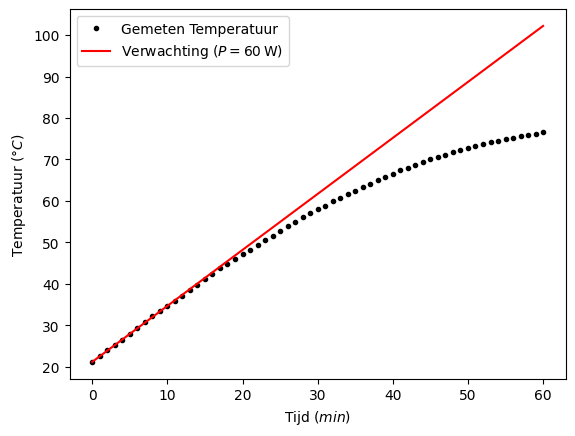

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Opdracht 1
data = np.genfromtxt(r"C:\Users\minev\Documents\TU\IP2\Project\thermolab\tempmetingen.csv", delimiter= ';', skip_header=1 )
tijd = data[:,0]
temp = data[:,1]

m_maatbeker = 0.8208 # kg
m_start = 1.2929 # kg
m_eind = 1.2749 # kg
m_w_start = m_start - m_maatbeker      # Startmassa water (kg)
m_w_verdamp = m_start - m_eind  # Verdampt water (kg)
temp_start = data[0,1] # Gemeten starttemperatuur
temp_eind = data[-1,1]  # Gemeten eindtemperatuur
tijd_eind_min = 60
tijd_eind_s = tijd_eind_min * 60

c_water = 4186   # J/(kg*K)
c_glas = 840     # J/(kg*K)

temp_10min = data[10,1]
delta_temp = temp_10min - temp_start
Q_opw = ((m_w_start * c_water) + (m_maatbeker * c_glas)) * delta_temp
P_verwarming = Q_opw / 600

def T_verwacht(t_min):
    t_s = t_min * 60
    return temp_start + (P_verwarming * t_s) / ((m_w_start * c_water) + (m_maatbeker * c_glas))

temp_verwacht = T_verwacht(tijd)

plt.figure()
plt.plot(tijd, temp, 'k.', label='Gemeten Temperatuur')
plt.plot(tijd, temp_verwacht, 'r-', label=f'Verwachting ($P = {int(round(P_verwarming))}\\,\\mathrm{{W}}$)')
plt.xlabel('Tijd $(min)$')
plt.ylabel('Temperatuur $(°C)$')
plt.legend()
plt.show()

In [ ]:
#Opdracht 2

L_v = 2257e3 # J/kg bij 100°C

# Totale Toegevoerde Energie
Q_in = P_verwarming * tijd_eind_s

Delta_T = temp_eind - temp_start
M_eff = (m_w_start * c_water) + (m_maatbeker * c_glas)
Q_opw = M_eff * Delta_T

Q_verd = m_w_verdamp * L_v

Q_verlies = Q_in - Q_opw - Q_verd

temp_verwacht_eind = T_verwacht(tijd_eind_min)

print('Toegevoerde energie is:', int(round(Q_in)), 'J')

Toegevoerde energie is: 215920 J


Opdracht 3:

Bepaal vermogen ($P$) direct met een watt-meter om het exacte vermogen van het verwarmingselement te meten in plaats van te schatten. Dit maakt $Q_{\mathrm{in}}$ exact.  Minimaliseer warmteverlies ($Q_{\mathrm{verlies}}$) door het experiment uit te voeren in een geïsoleerde container en gebruik een deksel om convectie en verdamping te minimaliseren. Dit maakt het resultaat nauwkeuriger en vermindert de onverklaarde $Q_{\mathrm{verlies}}$. Laat bovendien het experiment doorlopen tot het kookpunt 100 graden celcius om de latente warmte ($L_v$) directer te meten.
